In [1]:
# imports + setup for first-pass SROIE EDA
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from utils.data_utils import load_sroie_split, preview_record
from utils.eda_utils import (
    summarize_image_sizes,
    summarize_token_box_counts,
    summarize_field_presence,
    field_frequency_table,
    missingness_table,
    print_basic_dataset_summary,
    plot_histogram,
)

DATA_ROOT = PROJECT_ROOT / "Data"
SROIE_ROOT = DATA_ROOT / "SROIE"
SROIE_ROOT

PosixPath('/Users/quentin/Documents/Computer/School/CMU/Spring_2026/38616/Gated-Risk-MCP/Data/SROIE')

In [2]:
# load a small SROIE training sample first to verify folder and parser assumptions
sample_records = load_sroie_split("train", data_root=DATA_ROOT)
sample_records = sample_records[:10]
len(sample_records)

10

In [3]:
# inspect one SROIE record in compact form to verify the loader output
record = sample_records[0]
preview_record(record)

doc_id: X00016469612
dataset: SROIE
split: train
image_path: /Users/quentin/Documents/Computer/School/CMU/Spring_2026/38616/Gated-Risk-MCP/Data/SROIE/0325updated.task1train(626p)/X00016469612.jpg
image object present: False
image_size: None
num_tokens: 44
num_boxes: 44
num_fields: 4
field keys: ['company', 'date', 'address', 'total']
metadata keys: []


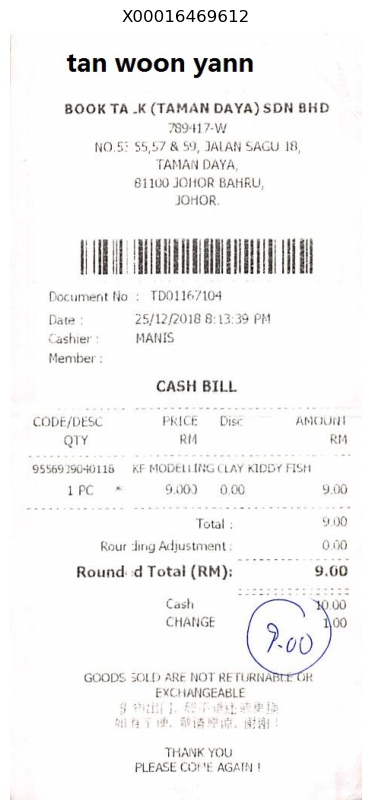

In [4]:
# visualize one SROIE example image using either an in-memory image or image path
img = record.image if record.image is not None else Image.open(record.image_path)
plt.figure(figsize=(8, 10))
plt.imshow(img)
plt.axis("off")
plt.title(record.doc_id)
plt.show()

In [5]:
# load the full SROIE training split and print a basic dataset summary
records = load_sroie_split("train", data_root=DATA_ROOT)
print_basic_dataset_summary(records)

Documents: 712
Datasets: {'SROIE': 712}
Splits: {'train': 712}

Token/box summary:
         n_tokens     n_boxes
count  712.000000  712.000000
mean    52.744382   52.744382
std     18.362251   18.362251
min      0.000000    0.000000
25%     41.000000   41.000000
50%     49.000000   49.000000
75%     62.000000   62.000000
max    153.000000  153.000000


In [6]:
# summarize image dimensions and aspect ratios for SROIE receipts
img_df = summarize_image_sizes(records)
display(img_df.head())
img_df[["width", "height", "aspect_ratio"]].describe()

,doc_id,dataset,split,width,height,aspect_ratio
0,X00016469612,SROIE,train,463,1013,0.457058
1,X00016469619,SROIE,train,439,1004,0.437251
2,X00016469620,SROIE,train,459,949,0.483667
3,X00016469622,SROIE,train,461,933,0.494105
4,X00016469623,SROIE,train,463,1026,0.451267


,width,height,aspect_ratio
count,712.000000,712.000000,712.000000
mean,1269.889045,2283.568820,0.511129
std,1345.629413,1753.298861,0.118331
min,436.000000,605.000000,0.263498
25%,623.000000,1402.000000,0.422162
50%,793.000000,1675.000000,0.497784
75%,934.000000,2086.750000,0.577567
max,4961.000000,7016.000000,0.971354


In [7]:
# inspect the top-level SROIE folders to verify actual directory names
sorted([p.name for p in SROIE_ROOT.iterdir()])

['.DS_Store',
 '0325updated.task1train(626p)',
 '0325updated.task2train(626p)',
 'task1&2_test(361p)',
 'task3-test 347p) -',
 'text.task1&2-test（361p)']

In [8]:
# inspect the contents of the likely image folder
train_img_dir = SROIE_ROOT / "0325updated.task1train(626p)"
sorted([p.name for p in train_img_dir.iterdir()])[:10]

['X00016469612.jpg',
 'X00016469612.txt',
 'X00016469619.jpg',
 'X00016469619.txt',
 'X00016469620.jpg',
 'X00016469620.txt',
 'X00016469622.jpg',
 'X00016469622.txt',
 'X00016469623.jpg',
 'X00016469623.txt']

In [9]:
# inspect the contents of the likely OCR folder candidates
for folder_name in [
    "0325updated.task2train(626p)",
    "0325updated.task3train(626p)",
    "text.task1&2-test(361p)",
    "task3-test(347p)",
]:
    folder = SROIE_ROOT / folder_name
    print("=" * 80)
    print(folder_name, folder.exists())
    if folder.exists():
        items = sorted([p.name for p in folder.iterdir()])[:10]
        print(items)

0325updated.task2train(626p) True
['X00016469612.jpg', 'X00016469612.txt', 'X00016469619.jpg', 'X00016469619.txt', 'X00016469620.jpg', 'X00016469620.txt', 'X00016469622.jpg', 'X00016469622.txt', 'X00016469623.jpg', 'X00016469623.txt']
0325updated.task3train(626p) False
text.task1&2-test(361p) False
task3-test(347p) False


In [10]:
# inspect one OCR/label file manually once the correct folder is identified
candidate_dir = SROIE_ROOT / "0325updated.task2train(626p)"
candidate_file = candidate_dir / "X00016469612.txt"
candidate_file.exists(), candidate_file

(True,
 PosixPath('/Users/quentin/Documents/Computer/School/CMU/Spring_2026/38616/Gated-Risk-MCP/Data/SROIE/0325updated.task2train(626p)/X00016469612.txt'))

In [11]:
# print the first few lines of a candidate OCR or label file
with open(candidate_file, "r", encoding="utf-8", errors="ignore") as f:
    for i in range(10):
        line = f.readline()
        if not line:
            break
        print(repr(line))

'{\n'
'    "company": "BOOK TA .K (TAMAN DAYA) SDN BHD",\n'
'    "date": "25/12/2018",\n'
'    "address": "NO.53 55,57 & 59, JALAN SAGU 18, TAMAN DAYA, 81100 JOHOR BAHRU, JOHOR.",\n'
'    "total": "9.00"\n'
'}'


In [12]:
# inspect whether task1train txt files are OCR text or label text
candidate_dir = SROIE_ROOT / "0325updated.task1train(626p)"
candidate_file = candidate_dir / "X00016469612.txt"

candidate_file.exists(), candidate_file

(True,
 PosixPath('/Users/quentin/Documents/Computer/School/CMU/Spring_2026/38616/Gated-Risk-MCP/Data/SROIE/0325updated.task1train(626p)/X00016469612.txt'))

In [13]:
# print the first few lines of a task1train txt file
with open(candidate_file, "r", encoding="utf-8", errors="ignore") as f:
    for i in range(10):
        line = f.readline()
        if not line:
            break
        print(repr(line))

'72,25,326,25,326,64,72,64,TAN WOON YANN\n'
'50,82,440,82,440,121,50,121,BOOK TA .K(TAMAN DAYA) SDN BND\n'
'205,121,285,121,285,139,205,139,789417-W\n'
'110,144,383,144,383,163,110,163,NO.53 55,57 & 59, JALAN SAGU 18,\n'
'192,169,299,169,299,187,192,187,TAMAN DAYA,\n'
'162,193,334,193,334,211,162,211,81100 JOHOR BAHRU,\n'
'217,216,275,216,275,233,217,233,JOHOR.\n'
'50,342,279,342,279,359,50,359,DOCUMENT NO : TD01167104\n'
'50,372,96,372,96,390,50,390,DATE:\n'
'165,372,342,372,342,389,165,389,25/12/2018 8:13:39 PM\n'


In [14]:
# inspect one task2train txt file to confirm the SROIE train labels are JSON key fields
label_dir = SROIE_ROOT / "0325updated.task2train(626p)"
label_file = label_dir / "X00016469612.txt"

with open(label_file, "r", encoding="utf-8", errors="ignore") as f:
    for i in range(10):
        line = f.readline()
        if not line:
            break
        print(repr(line))

'{\n'
'    "company": "BOOK TA .K (TAMAN DAYA) SDN BHD",\n'
'    "date": "25/12/2018",\n'
'    "address": "NO.53 55,57 & 59, JALAN SAGU 18, TAMAN DAYA, 81100 JOHOR BAHRU, JOHOR.",\n'
'    "total": "9.00"\n'
'}'


In [15]:
# reload the SROIE training sample after fixing the loader and confirm OCR + labels now populate
sample_records = load_sroie_split("train", data_root=DATA_ROOT)
sample_records = sample_records[:10]

record = sample_records[0]
preview_record(record)

doc_id: X00016469612
dataset: SROIE
split: train
image_path: /Users/quentin/Documents/Computer/School/CMU/Spring_2026/38616/Gated-Risk-MCP/Data/SROIE/0325updated.task1train(626p)/X00016469612.jpg
image object present: False
image_size: None
num_tokens: 44
num_boxes: 44
num_fields: 4
field keys: ['company', 'date', 'address', 'total']
metadata keys: []


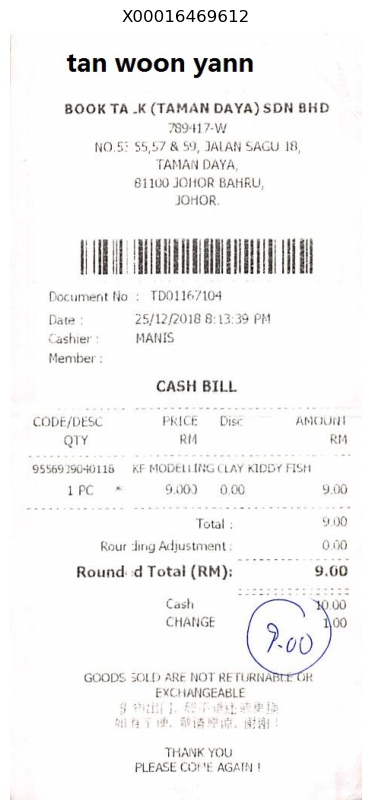

In [16]:
# visualize one SROIE example image after the loader fix
img = record.image if record.image is not None else Image.open(record.image_path)
plt.figure(figsize=(8, 10))
plt.imshow(img)
plt.axis("off")
plt.title(record.doc_id)
plt.show()

In [17]:
# inspect field presence and missingness for the four SROIE key extraction targets
presence = summarize_field_presence(records)
display(presence.head(20))

freq_df = field_frequency_table(records)
miss_df = missingness_table(presence)

display(freq_df.head(30))
display(miss_df.head(30))

,doc_id,dataset,split,n_fields,has_company,has_date,has_address,has_total
0,X00016469612,SROIE,train,4,1.0,1.0,1.0,1.0
1,X00016469619,SROIE,train,4,1.0,1.0,1.0,1.0
2,X00016469620,SROIE,train,4,1.0,1.0,1.0,1.0
3,X00016469622,SROIE,train,4,1.0,1.0,1.0,1.0
4,X00016469623,SROIE,train,4,1.0,1.0,1.0,1.0
5,X00016469669,SROIE,train,4,1.0,1.0,1.0,1.0
6,X00016469672,SROIE,train,4,1.0,1.0,1.0,1.0
7,X00016469676,SROIE,train,4,1.0,1.0,1.0,1.0
8,X51005200938,SROIE,train,4,1.0,1.0,1.0,1.0
9,X51005230617,SROIE,train,4,1.0,1.0,1.0,1.0


,field,doc_count,doc_fraction
0,company,669,0.939607
1,date,669,0.939607
2,address,668,0.938202
3,total,668,0.938202


,field,present_docs,missing_docs,missing_fraction
0,address,668,44,0.061798
1,total,668,44,0.061798
2,company,669,43,0.060393
3,date,669,43,0.060393


,doc_id,dataset,split,n_tokens,n_boxes
0,X00016469612,SROIE,train,44,44
1,X00016469619,SROIE,train,48,48
2,X00016469620,SROIE,train,54,54
3,X00016469622,SROIE,train,60,60
4,X00016469623,SROIE,train,61,61


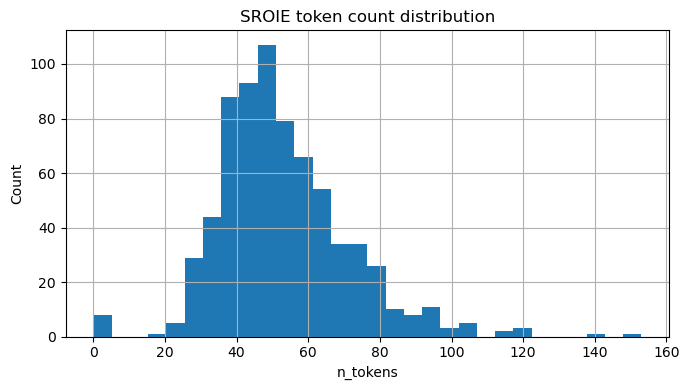

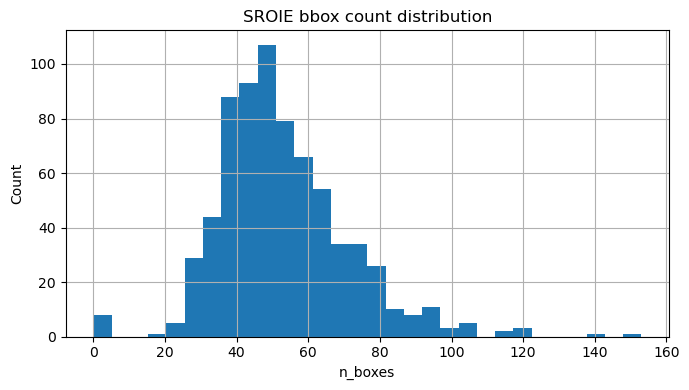

In [18]:
# inspect OCR token and bounding-box count distributions for SROIE
token_df = summarize_token_box_counts(records)
display(token_df.head())
plot_histogram(token_df, "n_tokens", bins=30, title="SROIE token count distribution")
plot_histogram(token_df, "n_boxes", bins=30, title="SROIE bbox count distribution")

In [20]:
# compare image size and OCR density to see whether larger receipts tend to contain more OCR text
merged_df = img_df.merge(token_df, on=["doc_id", "dataset", "split"], how="inner")
display(merged_df.head())
display(merged_df[["width", "height", "aspect_ratio", "n_tokens", "n_boxes"]].corr())

,doc_id,dataset,split,width,height,aspect_ratio,n_tokens,n_boxes
0,X00016469612,SROIE,train,463,1013,0.457058,44,44
1,X00016469619,SROIE,train,439,1004,0.437251,48,48
2,X00016469620,SROIE,train,459,949,0.483667,54,54
3,X00016469622,SROIE,train,461,933,0.494105,60,60
4,X00016469623,SROIE,train,463,1026,0.451267,61,61


,width,height,aspect_ratio,n_tokens,n_boxes
width,1.000000,0.982309,0.637470,0.042066,0.042066
height,0.982309,1.000000,0.495666,0.105518,0.105518
aspect_ratio,0.637470,0.495666,1.000000,-0.193303,-0.193303
n_tokens,0.042066,0.105518,-0.193303,1.000000,1.000000
n_boxes,0.042066,0.105518,-0.193303,1.000000,1.000000


In [21]:
# inspect a few raw SROIE label dictionaries to understand formatting variation in the target fields
for r in records[:10]:
    print("=" * 80)
    print(r.doc_id)
    print(r.fields)

X00016469612
{'company': 'BOOK TA .K (TAMAN DAYA) SDN BHD', 'date': '25/12/2018', 'address': 'NO.53 55,57 & 59, JALAN SAGU 18, TAMAN DAYA, 81100 JOHOR BAHRU, JOHOR.', 'total': '9.00'}
X00016469619
{'company': 'INDAH GIFT & HOME DECO', 'date': '19/10/2018', 'address': '27, JALAN DEDAP 13, TAMAN JOHOR JAYA, 81100 JOHOR BAHRU, JOHOR.', 'total': '60.30'}
X00016469620
{'company': 'MR D.I.Y. (JOHOR) SDN BHD', 'date': '12-01-19', 'address': 'LOT 1851-A & 1851-B, JALAN KPB 6, KAWASAN PERINDUSTRIAN BALAKONG, 43300 SERI KEMBANGAN, SELANGOR (MR DIY TESCO TERBAU)', 'total': '33.90'}
X00016469622
{'company': 'YONGFATT ENTERPRISE', 'date': '25/12/2018', 'address': 'NO 122.124. JALAN DEDAP 13 81100 JOHOR BAHRU', 'total': '80.90'}
X00016469623
{'company': 'MR D.I.Y. (M) SDN BHD', 'date': '18-11-18', 'address': 'LOT 1851-A & 1851-B, JALAN KPB 6, KAWASAN PERINDUSTRIAN BALAKONG, 43300 SERI KEMBANGAN, SELANGOR (TESCO PUTRA NILAI)', 'total': '30.90'}
X00016469669
{'company': 'ABC HO TRADING', 'date': '09/0

In [22]:
# summarize target-string lengths to compare difficulty across company, address, date, and total
rows = []
for r in records:
    fields = r.fields
    rows.append({
        "doc_id": r.doc_id,
        "company_len": len(str(fields.get("company", "")).strip()),
        "address_len": len(str(fields.get("address", "")).strip()),
        "date_len": len(str(fields.get("date", "")).strip()),
        "total_len": len(str(fields.get("total", "")).strip()),
    })

label_len_df = pd.DataFrame(rows)
display(label_len_df.describe())

,company_len,address_len,date_len,total_len
count,712.000000,712.000000,712.000000,712.000000
mean,23.209270,66.592697,9.004213,4.786517
std,9.203269,24.076177,2.469216,1.482932
min,0.000000,0.000000,0.000000,0.000000
25%,18.000000,54.000000,8.000000,4.000000
50%,22.000000,70.000000,10.000000,5.000000
75%,30.000000,84.000000,10.000000,5.000000
max,49.000000,135.000000,12.000000,8.000000


In [23]:
# check whether each labeled target appears verbatim somewhere in the OCR text
def contains_target(ocr_tokens, target):
    target = str(target).strip().lower()
    if target == "":
        return False
    joined = " ".join(ocr_tokens).lower()
    return target in joined

rows = []
for r in records:
    fields = r.fields
    ocr_tokens = r.ocr_tokens
    rows.append({
        "doc_id": r.doc_id,
        "company_in_ocr": contains_target(ocr_tokens, fields.get("company", "")),
        "address_in_ocr": contains_target(ocr_tokens, fields.get("address", "")),
        "date_in_ocr": contains_target(ocr_tokens, fields.get("date", "")),
        "total_in_ocr": contains_target(ocr_tokens, fields.get("total", "")),
    })

match_df = pd.DataFrame(rows)
display(match_df.mean(numeric_only=True).to_frame("fraction_verbatim_match"))

,fraction_verbatim_match
company_in_ocr,0.910112
address_in_ocr,0.075843
date_in_ocr,0.929775
total_in_ocr,0.933989


In [24]:
# compare OCR token counts for records with complete labels versus records with at least one missing label
rows = []
for r in records:
    fields = r.fields
    complete = all(str(fields.get(k, "")).strip() != "" for k in ["company", "address", "date", "total"])
    rows.append({
        "doc_id": r.doc_id,
        "is_complete_label": complete,
        "n_tokens": len(r.ocr_tokens),
    })

missing_compare_df = pd.DataFrame(rows)
display(missing_compare_df.groupby("is_complete_label")["n_tokens"].describe())

,count,mean,std,min,25%,50%,75%,max
is_complete_label,,,,,,,,
False,45.0,44.622222,23.215677,0.0,38.0,46.0,58.0,117.0
True,667.0,53.292354,17.877040,0.0,41.5,50.0,63.0,153.0


In [25]:
# measure how often each labeled target appears in some OCR token, not just the full joined OCR string
def token_contains_target(ocr_tokens, target):
    target = str(target).strip().lower()
    if target == "":
        return False
    return any(target in str(tok).strip().lower() for tok in ocr_tokens)

rows = []
for r in records:
    fields = r.fields
    toks = r.ocr_tokens
    rows.append({
        "doc_id": r.doc_id,
        "company_token_match": token_contains_target(toks, fields.get("company", "")),
        "address_token_match": token_contains_target(toks, fields.get("address", "")),
        "date_token_match": token_contains_target(toks, fields.get("date", "")),
        "total_token_match": token_contains_target(toks, fields.get("total", "")),
    })

token_match_df = pd.DataFrame(rows)
display(token_match_df.mean(numeric_only=True).to_frame("fraction_token_match"))

,fraction_token_match
company_token_match,0.846910
address_token_match,0.002809
date_token_match,0.929775
total_token_match,0.933989


,n_tokens,n_amount_like_tokens
count,712.000000,712.000000
mean,52.744382,12.875000
std,18.362251,9.735018
min,0.000000,0.000000
25%,41.000000,7.000000
50%,49.000000,11.000000
75%,62.000000,16.000000
max,153.000000,76.000000


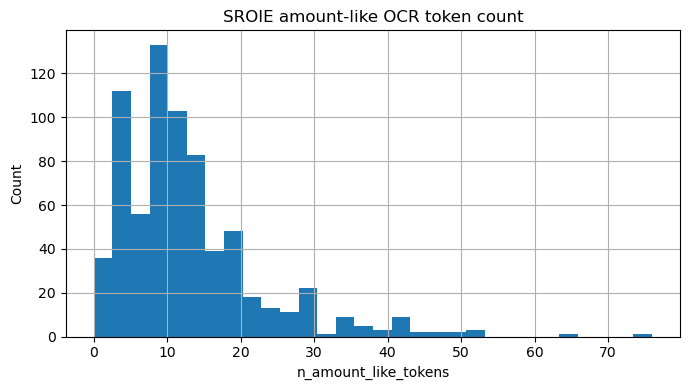

In [26]:
# count how many OCR tokens look like numeric amount candidates to estimate ambiguity for total extraction
import re

amount_pattern = re.compile(r"^\d+[.,]\d{2}$|^\d{1,3}(?:,\d{3})*(?:\.\d{2})?$")

rows = []
for r in records:
    amount_like = 0
    for tok in r.ocr_tokens:
        t = str(tok).strip()
        if amount_pattern.match(t):
            amount_like += 1
    rows.append({
        "doc_id": r.doc_id,
        "n_tokens": len(r.ocr_tokens),
        "n_amount_like_tokens": amount_like,
    })

amount_df = pd.DataFrame(rows)
display(amount_df.describe())
plot_histogram(amount_df, "n_amount_like_tokens", bins=30, title="SROIE amount-like OCR token count")

,n_date_like_tokens
count,712.000000
mean,0.174157
std,0.386852
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,2.000000


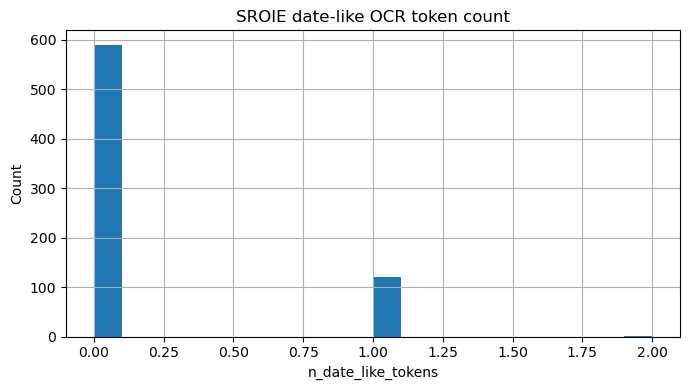

In [27]:
# count how many OCR tokens look like date candidates to estimate ambiguity for date extraction
date_patterns = [
    re.compile(r"^\d{2}/\d{2}/\d{4}$"),
    re.compile(r"^\d{2}-\d{2}-\d{2}$"),
    re.compile(r"^\d{2}-\d{2}-\d{4}$"),
    re.compile(r"^\d{4}/\d{2}/\d{2}$"),
]

def is_date_like(tok):
    t = str(tok).strip()
    return any(p.match(t) for p in date_patterns)

rows = []
for r in records:
    date_like = 0
    for tok in r.ocr_tokens:
        if is_date_like(tok):
            date_like += 1
    rows.append({
        "doc_id": r.doc_id,
        "n_date_like_tokens": date_like,
    })

date_df = pd.DataFrame(rows)
display(date_df.describe())
plot_histogram(date_df, "n_date_like_tokens", bins=20, title="SROIE date-like OCR token count")

In [28]:
# inspect a few high-token SROIE receipts to understand where OCR clutter and extraction ambiguity come from
top_dense = token_df.sort_values("n_tokens", ascending=False).head(10)
display(top_dense)

for doc_id in top_dense["doc_id"].head(3):
    r = next(rec for rec in records if rec.doc_id == doc_id)
    print("=" * 80)
    print(r.doc_id)
    print(r.fields)
    print(r.ocr_tokens[:40])

,doc_id,dataset,split,n_tokens,n_boxes
131,X51005663297,SROIE,train,153,153
620,X51007846368,SROIE,train,141,141
261,X51005806679,SROIE,train,119,119
14,X51005268472,SROIE,train,119,119
380,X51006414713,SROIE,train,118,118
137,X51005663324,SROIE,train,117,117
136,X51005663324(1),SROIE,train,117,117
39,X51005433533,SROIE,train,107,107
611,X51007846305,SROIE,train,105,105
322,X51006335552,SROIE,train,103,103


X51005663297
{'company': 'BEYOND BROTHERS HARDWARE', 'date': '14/03/2018', 'address': 'LOT 1-0-2, JLN 1/50, DIAMOND SQUARE, OFF JLN GOMBAK 53000 KUALA LUMPUR', 'total': '599.45'}
['BEYOND BROTHERS HARDWARE', '(872981-V)', 'LOT 1-0-2,JLN 1/50,', 'DIAMOND SQUARE,', 'OFF JLN GOMBAK', '53000 KUALA LUMPUR', 'TEL: 03-40211233', 'FAX: 03-40223233', 'IVAN_KONG12@HOTMAIL.COM', 'GST ID: 001921974272', 'TAX INVOICE', 'BILL TO:', 'PDP UTEK (M) SDN BHD', 'SEBELAH PETRONAS', 'AMPANG', 'NEAR TO KPJ HOSPITAL', '019-2616 281 MR.NEO', 'DOC NO.', ': CS00067741', 'DATE: 14/03/2018', 'CASHIER', ': USER', 'TIME: 16:37:00', 'SALESPERSON :', 'REF.:', 'ITEM', 'QTY', 'S/PRICE', '(GST)', 'S/PRICE', '(GST)', 'AMOUNT', 'TAX', '11028', '1', '150.00', '159.00', '159.00', 'SR', 'BATU CEMENT (A) 600PCS']
X51007846368
{'company': 'GRANDMA HOMES RESTAURANT', 'date': '13/06/2018', 'address': 'NO.3 & 5, JALAN PERMAS 11, BANDAR BARU PERMAS JAYA, 81750 MASAI, JOHOR', 'total': '473.30'}
['GRANDMA HOMES RESTAURANT', '(JM08408

,exact_total_matches,n_amount_like_tokens
count,712.000000,712.000000
mean,2.115169,12.875000
std,1.480561,9.735018
min,0.000000,0.000000
25%,1.000000,7.000000
50%,2.000000,11.000000
75%,3.000000,16.000000
max,7.000000,76.000000


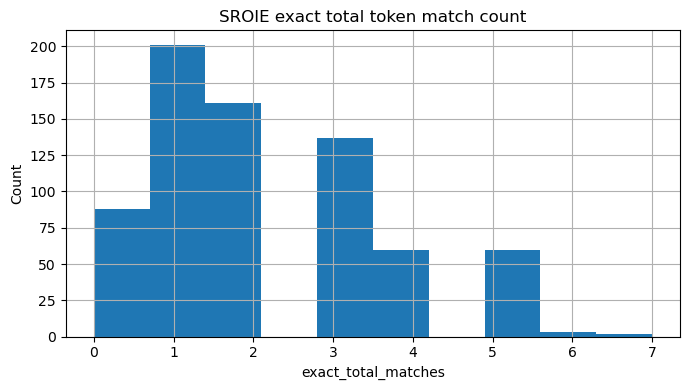

In [29]:
# count how many OCR tokens exactly equal the labeled total to measure candidate uniqueness for total extraction
rows = []
for r in records:
    total = str(r.fields.get("total", "")).strip().lower()
    toks = [str(tok).strip().lower() for tok in r.ocr_tokens]
    exact_total_matches = sum(tok == total for tok in toks) if total else 0
    rows.append({
        "doc_id": r.doc_id,
        "exact_total_matches": exact_total_matches,
        "n_amount_like_tokens": sum(amount_pattern.match(str(tok).strip()) is not None for tok in r.ocr_tokens),
    })

total_match_df = pd.DataFrame(rows)
display(total_match_df.describe())
plot_histogram(total_match_df, "exact_total_matches", bins=10, title="SROIE exact total token match count")

In [30]:
# check whether lexical anchors like TOTAL or DATE appear in the OCR for each receipt
def has_anchor(ocr_tokens, anchors):
    toks = [str(tok).strip().lower() for tok in ocr_tokens]
    joined = " ".join(toks)
    return any(a in joined for a in anchors)

rows = []
for r in records:
    rows.append({
        "doc_id": r.doc_id,
        "has_total_anchor": has_anchor(r.ocr_tokens, ["total", "amt", "amount", "grand total", "nett"]),
        "has_date_anchor": has_anchor(r.ocr_tokens, ["date", "dated"]),
        "has_cash_anchor": has_anchor(r.ocr_tokens, ["cash", "change"]),
    })

anchor_df = pd.DataFrame(rows)
display(anchor_df.mean(numeric_only=True).to_frame("fraction_with_anchor"))

,fraction_with_anchor
has_total_anchor,0.987360
has_date_anchor,0.542135
has_cash_anchor,0.967697


In [31]:
# compare amount ambiguity between receipts where the true total appears verbatim and receipts where it does not
rows = []
for r in records:
    total = str(r.fields.get("total", "")).strip().lower()
    toks = [str(tok).strip().lower() for tok in r.ocr_tokens]
    rows.append({
        "doc_id": r.doc_id,
        "total_in_ocr": total in " ".join(toks) if total else False,
        "n_amount_like_tokens": sum(amount_pattern.match(str(tok).strip()) is not None for tok in r.ocr_tokens),
        "n_tokens": len(r.ocr_tokens),
    })

total_ambiguity_df = pd.DataFrame(rows)
display(total_ambiguity_df.groupby("total_in_ocr")[["n_amount_like_tokens", "n_tokens"]].describe())

n_amount_like_tokens                                             \
                            count       mean       std  min  25%   50%   75%   
total_in_ocr                                                                   
False                        47.0  10.234043  8.668315  0.0  4.0   9.0  16.0   
True                        665.0  13.061654  9.784921  0.0  7.0  11.0  16.0   

                   n_tokens                                                \
               max    count       mean        std   min   25%   50%   75%   
total_in_ocr                                                                
False         43.0     47.0  42.617021  24.405588   0.0  38.0  46.0  56.5   
True          76.0    665.0  53.460150  17.663573  18.0  42.0  50.0  63.0   

                     
                max  
total_in_ocr         
False         117.0  
True          153.0

In [32]:
# inspect a few receipts where address is labeled but not verbatim recoverable from OCR to understand address difficulty
hard_address_docs = []
for r in records:
    address = str(r.fields.get("address", "")).strip().lower()
    joined = " ".join(str(tok).strip().lower() for tok in r.ocr_tokens)
    if address and address not in joined:
        hard_address_docs.append(r.doc_id)

print(hard_address_docs[:10])

for doc_id in hard_address_docs[:3]:
    r = next(rec for rec in records if rec.doc_id == doc_id)
    print("=" * 80)
    print(r.doc_id)
    print("LABEL ADDRESS:", r.fields.get("address"))
    print("OCR TOKENS:", r.ocr_tokens[:25])

['X00016469612', 'X00016469619', 'X00016469620', 'X00016469622', 'X00016469623', 'X00016469669', 'X00016469672', 'X00016469676', 'X51005230617', 'X51005268200']
X00016469612
LABEL ADDRESS: NO.53 55,57 & 59, JALAN SAGU 18, TAMAN DAYA, 81100 JOHOR BAHRU, JOHOR.
OCR TOKENS: ['TAN WOON YANN', 'BOOK TA .K(TAMAN DAYA) SDN BND', '789417-W', 'NO.53 55,57 & 59,JALAN SAGU 18,', 'TAMAN DAYA,', '81100 JOHOR BAHRU,', 'JOHOR.', 'DOCUMENT NO : TD01167104', 'DATE:', '25/12/2018 8:13:39 PM', 'CASHIER:', 'MANIS', 'MEMBER:', 'CASH BILL', 'CODE/DESC', 'PRICE', 'DISC', 'AMOUNT', 'QTY', 'RM', 'RM', '9556939040116', 'KF MODELLING CLAY KIDDY FISH', '1 PC', '*']
X00016469619
LABEL ADDRESS: 27, JALAN DEDAP 13, TAMAN JOHOR JAYA, 81100 JOHOR BAHRU, JOHOR.
OCR TOKENS: ['TAN WOON YANN', 'INDAH GIFT & HOME DECO', '27,JALAN DEDAP 13,', 'TAMAN JOHOR JAYA,', '81100 JOHOR BAHRU,JOHOR.', 'TEL:07-3507405', 'FAX:07-3558160', 'RECEIPT', '19/10/2018 20:49:59 #01', 'CASHIER: CN', 'LOCATION/SP: 05 /0531', 'MB: MO26588', 'ROOM 

In [33]:
# compare field lengths and OCR evidence between receipts where each target is verbatim recoverable versus not
rows = []
for r in records:
    joined = " ".join(str(tok).strip().lower() for tok in r.ocr_tokens)
    fields = r.fields
    for field in ["company", "address", "date", "total"]:
        target = str(fields.get(field, "")).strip().lower()
        rows.append({
            "doc_id": r.doc_id,
            "field": field,
            "target_len": len(target),
            "in_ocr": target in joined if target else False,
            "n_tokens": len(r.ocr_tokens),
            "n_amount_like_tokens": sum(amount_pattern.match(str(tok).strip()) is not None for tok in r.ocr_tokens),
            "n_date_like_tokens": sum(is_date_like(tok) for tok in r.ocr_tokens),
        })

field_match_detail_df = pd.DataFrame(rows)
display(field_match_detail_df.groupby(["field", "in_ocr"])[["target_len", "n_tokens", "n_amount_like_tokens", "n_date_like_tokens"]].mean())

target_len   n_tokens  n_amount_like_tokens  \
field   in_ocr                                                
address False    67.176292  52.808511             13.000000   
        True     59.481481  51.962963             11.351852   
company False     8.906250  47.093750             11.796875   
        True     24.621914  53.302469             12.981481   
date    False     1.300000  42.760000              9.940000   
        True      9.586103  53.498489             13.096677   
total   False     0.361702  42.617021             10.234043   
        True      5.099248  53.460150             13.061654   

                n_date_like_tokens  
field   in_ocr                      
address False             0.176292  
        True              0.148148  
company False             0.125000  
        True              0.179012  
date    False             0.120000  
        True              0.178248  
total   False             0.085106  
        True              0.180451

In [34]:
# inspect a few receipts where total is labeled but not verbatim present in OCR to understand total failure modes
hard_total_docs = []
for r in records:
    total = str(r.fields.get("total", "")).strip().lower()
    joined = " ".join(str(tok).strip().lower() for tok in r.ocr_tokens)
    if total and total not in joined:
        hard_total_docs.append(r.doc_id)

print(hard_total_docs[:10])

for doc_id in hard_total_docs[:3]:
    r = next(rec for rec in records if rec.doc_id == doc_id)
    print("=" * 80)
    print(r.doc_id)
    print("LABEL TOTAL:", r.fields.get("total"))
    print("OCR TOKENS:", r.ocr_tokens[:40])

['X51005676539(1)', 'X51005806678', 'X51007339647(1)']
X51005676539(1)
LABEL TOTAL: 23.32
OCR TOKENS: []
X51005806678
LABEL TOTAL: 7838.80
OCR TOKENS: ['KAISON FURNISHING SDN BHD', 'L4-17 (B),LEVEL 4,', 'UP2-01,MELAWATI MALL,', '355,JALAN BANDAR MELAWATI,', 'PUSAT BANDAR MELAWATI,', '53100 KUALA LUMPUR.', 'CO. REG NO. (761834-D)', 'GST REG NO. 001813975040', 'TEL : 03 - 41019864', 'SLIP', '0000MLW-P3000024348', 'STAFF:', '1799 SITI IZZA', 'TRANS:', '1603029175', 'DATE:', '29-01-18 20:38', 'DESCRIPTION', 'AMOUNT(RM)', 'BARCODE:', '10182079', 'FLOWER BUNCH -', 'ROSE', '122 PCS @ 18.90', '2,305.80 SR', 'ITEM NO. :', '30001640', 'FLOWER BUNCH - CRYST', '240 PCS @ 13.90', '3,336.00 SR', 'ITEM NO. :', '30001635', 'FLOWER BUNCH - 7HD P', '130 PCS @ 16.90', '2,197.00 SR', 'TOTAL RM', 'CASH (MYR)', 'CHANGE', '7,838.80', '-7,840.00']
X51007339647(1)
LABEL TOTAL: 16.00
OCR TOKENS: []


In [35]:
# inspect a few receipts where company is labeled but not verbatim present in OCR to understand company mismatch modes
hard_company_docs = []
for r in records:
    company = str(r.fields.get("company", "")).strip().lower()
    joined = " ".join(str(tok).strip().lower() for tok in r.ocr_tokens)
    if company and company not in joined:
        hard_company_docs.append(r.doc_id)

print(hard_company_docs[:10])

for doc_id in hard_company_docs[:3]:
    r = next(rec for rec in records if rec.doc_id == doc_id)
    print("=" * 80)
    print(r.doc_id)
    print("LABEL COMPANY:", r.fields.get("company"))
    print("OCR TOKENS:", r.ocr_tokens[:30])

['X00016469612', 'X00016469620', 'X51005361907(1)', 'X51005361907', 'X51005441398', 'X51005442361', 'X51005605333', 'X51005676539(1)', 'X51005711451', 'X51005712021']
X00016469612
LABEL COMPANY: BOOK TA .K (TAMAN DAYA) SDN BHD
OCR TOKENS: ['TAN WOON YANN', 'BOOK TA .K(TAMAN DAYA) SDN BND', '789417-W', 'NO.53 55,57 & 59,JALAN SAGU 18,', 'TAMAN DAYA,', '81100 JOHOR BAHRU,', 'JOHOR.', 'DOCUMENT NO : TD01167104', 'DATE:', '25/12/2018 8:13:39 PM', 'CASHIER:', 'MANIS', 'MEMBER:', 'CASH BILL', 'CODE/DESC', 'PRICE', 'DISC', 'AMOUNT', 'QTY', 'RM', 'RM', '9556939040116', 'KF MODELLING CLAY KIDDY FISH', '1 PC', '*', '9.000', '0.00', '9.00', 'TOTAL:', 'ROUR DING ADJUSTMENT:']
X00016469620
LABEL COMPANY: MR D.I.Y. (JOHOR) SDN BHD
OCR TOKENS: ['TAN WOON YANN', 'MR D.T.Y. (JOHOR) SDN BHD', '(CO.REG : 933109-X)', 'LOT 1851-A & 1851-B,JALAN KPB 6,', 'KAWASAN PERINDUSTRIAN BALAKONG,', '43300 SERI KEMBANGAN,SELANGOR', '(MR DIY TESCO TERBAU)', '-INVOICE-', 'CHOPPING BOARD 35.5X25.5CM 803M#', 'EZ10HD05 - 2

In [36]:
# compute simple fuzzy containment scores between OCR text and the labeled company/address fields
from difflib import SequenceMatcher

def fuzzy_ratio(a, b):
    a = str(a).strip().lower()
    b = str(b).strip().lower()
    if not a or not b:
        return 0.0
    return SequenceMatcher(None, a, b).ratio()

rows = []
for r in records:
    joined = " ".join(str(tok).strip() for tok in r.ocr_tokens)
    rows.append({
        "doc_id": r.doc_id,
        "company_fuzzy": fuzzy_ratio(r.fields.get("company", ""), joined),
        "address_fuzzy": fuzzy_ratio(r.fields.get("address", ""), joined),
    })

fuzzy_df = pd.DataFrame(rows)
display(fuzzy_df.describe())

,company_fuzzy,address_fuzzy
count,712.000000,712.000000
mean,0.067983,0.168516
std,0.031753,0.080270
min,0.000000,0.000000
25%,0.053258,0.119401
50%,0.067890,0.170702
75%,0.087719,0.224704
max,0.188172,0.406780


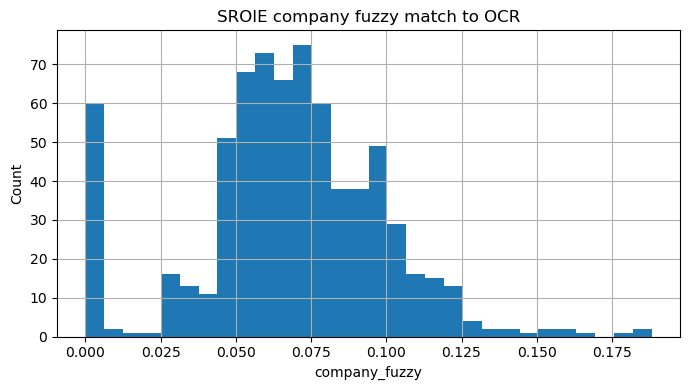

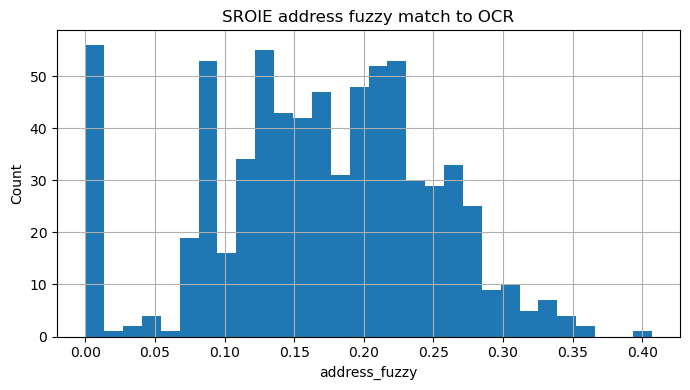

In [37]:
# inspect fuzzy-match distributions for company and address against the full OCR text
plot_histogram(fuzzy_df, "company_fuzzy", bins=30, title="SROIE company fuzzy match to OCR")
plot_histogram(fuzzy_df, "address_fuzzy", bins=30, title="SROIE address fuzzy match to OCR")

In [38]:
# inspect a few low-company-fuzzy and low-address-fuzzy examples to understand residual failure modes
print("Low company fuzzy examples:")
for doc_id in fuzzy_df.sort_values("company_fuzzy").head(3)["doc_id"]:
    r = next(rec for rec in records if rec.doc_id == doc_id)
    print("=" * 80)
    print(r.doc_id)
    print("LABEL COMPANY:", r.fields.get("company"))
    print("OCR TOKENS:", r.ocr_tokens[:25])

print("\nLow address fuzzy examples:")
for doc_id in fuzzy_df.sort_values("address_fuzzy").head(3)["doc_id"]:
    r = next(rec for rec in records if rec.doc_id == doc_id)
    print("=" * 80)
    print(r.doc_id)
    print("LABEL ADDRESS:", r.fields.get("address"))
    print("OCR TOKENS:", r.ocr_tokens[:25])

Low company fuzzy examples:
X51006334926(2)
LABEL COMPANY: None
OCR TOKENS: ['YOUR ORDER NUMBER IS', '264', 'GOLDEN ARCHES RESTAURANTS SDN BHD', '(65351-M)', 'LEVEL 6,BANGUNAN TH,DAMANSARA UPTOWN3', 'NO.3,JALAN SS21/39,47400 PETALING JAYA', 'SELANGOR', '(GST ID NO: 000504664064)', "MCDONALD'S KOTA DAMANSARA DT(#178)", 'TEL NO. 03-6156-2180', 'TAX INVOICE', 'MFY SIDE 1', 'INV# 001780200112117', 'ORD #64 -REG #2- 25/12/2016 13:51:47', 'THANK YOU AND PLEASE COME AGAIN.', 'QTY ITEM', 'TOTAL', '2 L FILETOFISH', '21.18', '2 L COKE', 'NO ICE', '2 L FRIES', '1 6NUGGETS', '7.10', '1 BARBECUE SAUCE']
X51005677334(2)
LABEL COMPANY: None
OCR TOKENS: ['SYARIKAT PERNIAGAAN GIN KEE', '(81109-A)', 'NO 290,JALAN AIR PANAS.', 'SETAPAK,', '53200,KUALA LUMPUR.', 'TEL : 03-40210276', 'GST ID : 000750673920', 'SIMPLIFIED TAX INVOICE', 'CASH', 'DOC NO.', 'CASHIER', 'SALESPERSON :', 'GOODS SOLD ARE NOT RETURNABLE,THANK YOU', '4.68', '78.00', ': CS00013066', ': USER', 'DATE: 31/01/2018', 'TIME: 11:33:00', 'REF

In [39]:
# inspect the small set of zero-token SROIE receipts to see whether they are corrupted files or loader edge cases
zero_token_docs = token_df[token_df["n_tokens"] == 0]
display(zero_token_docs)

for doc_id in zero_token_docs["doc_id"].head(5):
    r = next(rec for rec in records if rec.doc_id == doc_id)
    print("=" * 80)
    print(r.doc_id)
    print(r.fields)
    print(r.ocr_path)

,doc_id,dataset,split,n_tokens,n_boxes
34,X51005433492(1),SROIE,train,0,0
64,X51005442384(1),SROIE,train,0,0
119,X51005605333(1),SROIE,train,0,0
144,X51005676539(1),SROIE,train,0,0
169,X51005685355(2),SROIE,train,0,0
172,X51005685357(2),SROIE,train,0,0
566,X51007339118(1),SROIE,train,0,0
593,X51007339647(1),SROIE,train,0,0


X51005433492(1)
{}
/Users/quentin/Documents/Computer/School/CMU/Spring_2026/38616/Gated-Risk-MCP/Data/SROIE/0325updated.task1train(626p)/X51005433492(1).txt
X51005442384(1)
{}
/Users/quentin/Documents/Computer/School/CMU/Spring_2026/38616/Gated-Risk-MCP/Data/SROIE/0325updated.task1train(626p)/X51005442384(1).txt
X51005605333(1)
{}
/Users/quentin/Documents/Computer/School/CMU/Spring_2026/38616/Gated-Risk-MCP/Data/SROIE/0325updated.task1train(626p)/X51005605333(1).txt
X51005676539(1)
{'company': 'SYARIKAT PERNIAGAAN GIN KEE', 'date': '10/01/2018', 'address': 'NO 290, JALAN AIR PANAS, SETAPAK, 53200, KUALA LUMPUR.', 'total': '23.32'}
/Users/quentin/Documents/Computer/School/CMU/Spring_2026/38616/Gated-Risk-MCP/Data/SROIE/0325updated.task1train(626p)/X51005676539(1).txt
X51005685355(2)
{}
/Users/quentin/Documents/Computer/School/CMU/Spring_2026/38616/Gated-Risk-MCP/Data/SROIE/0325updated.task1train(626p)/X51005685355(2).txt
